In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Melbourne%20Housing%20dataset/melbourne_housing.csv"

print("Starting data migration from GitHub...")

try:
    df = pd.read_csv(url)

    print("Data loaded successfully")

except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [2]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,City,SellingDate
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,3067.0,2.0,...,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Melbourne,3/09/2016
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,3067.0,2.0,...,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0,Melbourne,3/12/2016
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,3067.0,2.0,...,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0,Melbourne,4/02/2016
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,3067.0,3.0,...,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0,Melbourne,4/02/2016
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,3067.0,3.0,...,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0,Melbourne,4/03/2017


In [3]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount', 'City', 'SellingDate'],
      dtype='object')

In [4]:
df.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Price             object
Method            object
SellerG           object
Date              object
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car               object
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
City              object
SellingDate       object
dtype: object

# Remove data without variance and duplicates

Print a column "City"

In [5]:
df['City']

0        Melbourne
1        Melbourne
2        Melbourne
3        Melbourne
4        Melbourne
           ...    
36595    Melbourne
36596    Melbourne
36597    Melbourne
36598    Melbourne
36599    Melbourne
Name: City, Length: 36600, dtype: object

In [6]:
df['City'].unique()

array(['Melbourne'], dtype=object)

In [7]:
df.drop(columns=['City'], inplace=True)

In [8]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Bedroom2,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,SellingDate
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,3067.0,2.0,...,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,3/09/2016
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,3067.0,2.0,...,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0,3/12/2016
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,3067.0,2.0,...,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0,4/02/2016
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,3067.0,3.0,...,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0,4/02/2016
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,3067.0,3.0,...,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0,4/03/2017


In [9]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount', 'SellingDate'],
      dtype='object')

We have Date + SellingDate: Are they duplicates?

In [10]:
df['Date'].equals(df['SellingDate'])

True

In [11]:
df.drop(columns='SellingDate', inplace=True)

In [12]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount'],
      dtype='object')

Remove duplicate rows

In [13]:
print(f'rows before duplicate removal: {len(df)}')
print(f'columns:{len(df.columns)}')

rows before duplicate removal: 36600
columns:20


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
print(f'rows after duplicate removal: {len(df)}')

rows after duplicate removal: 34861


# Select relevant columns

In [16]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount'],
      dtype='object')

In [17]:
# we could also just drop Address and the Seller
# this is a selection
df = df[["Price", "Suburb", "Rooms", "Type", "Method", "Date", "Postcode", "Bedroom2", "Bathroom", "Car",
         "Landsize", "BuildingArea", "YearBuilt", "CouncilArea", "Lattitude", "Longtitude", "Regionname",
         "Propertycount"]]

In [18]:
df.columns

Index(['Price', 'Suburb', 'Rooms', 'Type', 'Method', 'Date', 'Postcode',
       'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt',
       'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname',
       'Propertycount'],
      dtype='object')

The column Bedroom2 should be renamed to Bedrooms and the columns Lattitude and Longtitude have typos. Rename these three columns!

In [19]:
df.rename(columns={'Bedroom2' : 'Bedrooms',
                   'Lattitude' : 'Latitude',
                   'Longtitude' : 'Longitude'}, inplace = True)

In [20]:
df.columns

Index(['Price', 'Suburb', 'Rooms', 'Type', 'Method', 'Date', 'Postcode',
       'Bedrooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt',
       'CouncilArea', 'Latitude', 'Longitude', 'Regionname', 'Propertycount'],
      dtype='object')

# Unify columns

Type column specifies property type. Print all unique values.

In [21]:
df['Type'].unique()

array(['h', 'u', 't', 'unknown'], dtype=object)

Replace values with more intuitive values. See kaggle link for further information.

In [22]:
type_dict = dict()
type_dict['h'] = 'House'
type_dict['u'] = 'Unit / Duplex'
type_dict['t'] = 'Townhouse'
type_dict['unknown'] = 'Other'

def replace_type (row):
    if row['Type'] in type_dict:
        return type_dict[row['Type']]
    return row['Type']

df['Type'] = df.apply(replace_type, axis=1)


Verify that replacement was correct. Print unique values again!

In [23]:
df['Type'].unique()

array(['House', 'Unit / Duplex', 'Townhouse', 'Other'], dtype=object)

Let us consider the "Car" column. Print the unique values!

In [24]:
df['Car'].unique()

array(['1.0', '0.0', '2.0', nan, '6.0', '5.0', '3.0', '4.0', '8.0', '7.0',
       'two', '11.0', '26.0', '9.0', '10.0', '18.0', '12.0'], dtype=object)

In [25]:
mapping = dict()
mapping['two'] = '2'

def unify_car(row):
    if row['Car'] in mapping:
        return mapping[row['Car']]
    return row['Car']

df['Car'] = df.apply(unify_car, axis=1)

In [26]:
df['Car'].unique()

array(['1.0', '0.0', '2.0', nan, '6.0', '5.0', '3.0', '4.0', '8.0', '7.0',
       '2', '11.0', '26.0', '9.0', '10.0', '18.0', '12.0'], dtype=object)

In [27]:
df['Car'] = pd.to_numeric(df['Car'], errors='coerce')

In [28]:
df['Car'].unique()

array([ 1.,  0.,  2., nan,  6.,  5.,  3.,  4.,  8.,  7., 11., 26.,  9.,
       10., 18., 12.])

Convert the price column to numeric. Check data summary statistics before and after conversion.

In [29]:
df['Price'].describe()

count        24497
unique        2757
top       600000.0
freq           214
Name: Price, dtype: object

In [30]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Price'].describe()

count    2.449200e+04
mean     1.052254e+06
std      6.446110e+05
min      8.500000e+04
25%      6.359500e+05
50%      8.722500e+05
75%      1.300000e+06
max      1.120000e+07
Name: Price, dtype: float64

# Handle data errors and outliers

Generate statistics of all columns

In [31]:
df.describe()

,Price,Rooms,Postcode,Bedrooms,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,Longitude,Propertycount
count,2.449200e+04,34861.000000,34860.000000,26643.000000,26634.000000,23479.000000,2.305000e+04,12351.000000,15553.000000,26884.000000,26884.000000,34858.000000
mean,1.052254e+06,3.076217,3116.067413,3.084675,1.624803,1.728012,9.986328e+03,160.806694,1965.286440,-37.810648,145.001850,7572.939038
std,6.446110e+05,2.829575,109.020214,0.980651,0.724189,1.010278,4.508708e+05,422.279704,37.327927,0.090304,0.120161,4427.892963
min,8.500000e+04,1.000000,3000.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1196.000000,-38.190430,144.423790,83.000000
25%,6.359500e+05,2.000000,3051.000000,2.000000,1.000000,1.000000,2.240000e+02,102.000000,1940.000000,-37.862962,144.933500,4385.000000
50%,8.722500e+05,3.000000,3103.000000,3.000000,2.000000,2.000000,5.210000e+02,136.000000,1970.000000,-37.807600,145.007800,6763.000000
75%,1.300000e+06,4.000000,3156.000000,4.000000,2.000000,2.000000,6.700000e+02,187.000000,2000.000000,-37.754092,145.071900,10412.000000
max,1.120000e+07,160.000000,3978.000000,30.000000,12.000000,26.000000,2.165070e+07,44515.000000,2106.000000,-37.390200,145.526350,21650.000000


Print summary statistics of YearBuilt

In [32]:
df['YearBuilt'].describe()

count    15553.000000
mean      1965.286440
std         37.327927
min       1196.000000
25%       1940.000000
50%       1970.000000
75%       2000.000000
max       2106.000000
Name: YearBuilt, dtype: float64

Print rows with YearBuilt < 1800

In [33]:
df_old = df[df['YearBuilt'] < 1800]
df_old

,Price,Suburb,Rooms,Type,Method,Date,Postcode,Bedrooms,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount
16424,1200000.0,Mount Waverley,3,House,VB,24/06/2017,3149.0,3.0,1.0,4.0,807.0,117.0,1196.0,Monash City Council,-37.86788,145.12121,Eastern Metropolitan,13366.0


Print rows with YearBuilt > 2025

In [34]:
df_future = df[df["YearBuilt"] > 2025]
df_future

,Price,Suburb,Rooms,Type,Method,Date,Postcode,Bedrooms,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount
2453,NaN,Bulleen,4,House,SP,7/11/2016,3105.0,4.0,2.0,2.0,729.0,255.0,2106.0,Manningham City Council,-37.7637,145.0881,Eastern Metropolitan,4480.0


2106 is probably 2016 and 1196 probably 1996. Fix these values accordingly. Verify the summary statistics after replacement.


In [35]:
df.loc[df['YearBuilt']==1196, 'YearBuilt'] = 1996
df.loc[df['YearBuilt']==2106, 'YearBuilt'] = 2016

df['YearBuilt'].describe()

count    15553.000000
mean      1965.332090
std         36.800433
min       1800.000000
25%       1940.000000
50%       1970.000000
75%       2000.000000
max       2019.000000
Name: YearBuilt, dtype: float64

Let us also look at room and land size

In [36]:
df["Rooms"].describe()

count    34861.000000
mean         3.076217
std          2.829575
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max        160.000000
Name: Rooms, dtype: float64

In [37]:
df["Landsize"].describe()

count    2.305000e+04
mean     9.986328e+03
std      4.508708e+05
min      0.000000e+00
25%      2.240000e+02
50%      5.210000e+02
75%      6.700000e+02
max      2.165070e+07
Name: Landsize, dtype: float64

We do not know how many rooms the buildings have and what the actual landsize is. We apply winsorizing at the 1%-level but only for the upper quantile.

In [38]:
upper = df['Rooms'].quantile(0.99)

df['Rooms_winsorized'] = df['Rooms'].clip(upper =  upper)
df['Rooms_winsorized'].describe()

count    34861.000000
mean         3.020194
std          0.931500
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Rooms_winsorized, dtype: float64

In [39]:
upper = df['Landsize'].quantile(0.99)

df['Landsize_winsorized'] = df['Landsize'].clip(upper = upper)
df['Landsize_winsorized'].describe()

count    23050.000000
mean       506.142560
std        427.392731
min          0.000000
25%        224.000000
50%        521.000000
75%        670.000000
max       3093.000000
Name: Landsize_winsorized, dtype: float64

Check summary statistics of Building Area

In [40]:
df['BuildingArea'].describe()

count    12351.000000
mean       160.806694
std        422.279704
min          0.000000
25%        102.000000
50%        136.000000
75%        187.000000
max      44515.000000
Name: BuildingArea, dtype: float64

Winsorize at 1%-level but only the upper quantile

In [41]:
upper = df['BuildingArea'].quantile(0.99)

df['BuildingArea_winsorized'] = df['BuildingArea'].clip(upper = upper)
df['BuildingArea_winsorized'].describe()

count    12351.000000
mean       153.529177
std         80.706844
min          0.000000
25%        102.000000
50%        136.000000
75%        187.000000
max        477.500000
Name: BuildingArea_winsorized, dtype: float64

# Handle missing data

Print all columns that have NaN

In [42]:
df.columns[df.isna().any()]

Index(['Price', 'Postcode', 'Bedrooms', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longitude',
       'Regionname', 'Propertycount', 'Landsize_winsorized',
       'BuildingArea_winsorized'],
      dtype='object')

Let us start by fixing the price as this is our target column (i.e., the column we want to predict or explain). Print all rows where price is NA!

In [43]:
df_price_na = df[df['Price'].isna()]
df_price_na

,Price,Suburb,Rooms,Type,Method,Date,Postcode,Bedrooms,Bathroom,Car,...,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount,Rooms_winsorized,Landsize_winsorized,BuildingArea_winsorized
0,NaN,Abbotsford,2,House,SS,3/09/2016,3067.0,2.0,1.0,1.0,...,NaN,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0,2,126.0,NaN
3,NaN,Abbotsford,3,Unit / Duplex,VB,4/02/2016,3067.0,3.0,2.0,1.0,...,NaN,NaN,Yarra City Council,-37.81140,145.01160,Northern Metropolitan,4019.0,3,0.0,NaN
6,NaN,Abbotsford,4,House,VB,4/06/2016,3067.0,3.0,1.0,2.0,...,142.0,2014.0,Yarra City Council,-37.80720,144.99410,Northern Metropolitan,4019.0,4,120.0,142.0
7,NaN,Abbotsford,4,House,SN,6/08/2016,3067.0,3.0,2.0,2.0,...,220.0,2006.0,Yarra City Council,-37.79650,144.99650,Northern Metropolitan,4019.0,4,400.0,220.0
8,NaN,Abbotsford,2,House,S,6/08/2016,3067.0,4.0,1.0,2.0,...,NaN,1900.0,Yarra City Council,-37.79950,144.99740,Northern Metropolitan,4019.0,2,201.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35196,NaN,Camberwell,4,House,PI,28/10/2017,3124.0,4.0,3.0,3.0,...,175.0,1920.0,Boroondara City Council,-37.84082,145.06167,Southern Metropolitan,8920.0,4,NaN,175.0
35222,NaN,Brighton,3,House,PI,6/01/2018,3186.0,3.0,2.0,2.0,...,118.0,1953.0,Bayside City Council,-37.92276,144.99957,Southern Metropolitan,10579.0,3,386.0,118.0
35580,NaN,Fawkner,3,Townhouse,S,26/08/2017,3060.0,3.0,2.0,2.0,...,120.0,2004.0,Hume City Council,-37.71021,144.96392,Northern Metropolitan,5070.0,3,NaN,120.0
35697,NaN,Frankston South,3,Other,SA,24/02/2018,3199.0,3.0,1.0,1.0,...,NaN,NaN,Frankston City Council,-38.15969,145.11413,South-Eastern Metropolitan,7566.0,3,697.0,NaN


We drop all rows without price. Imputation is generally not reasonable for target variables.

In [44]:
df.dropna(subset=['Price'], inplace=True)

In [45]:
df.columns[df.isna().any()]

Index(['Postcode', 'Bedrooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
       'YearBuilt', 'CouncilArea', 'Latitude', 'Longitude', 'Regionname',
       'Propertycount', 'Landsize_winsorized', 'BuildingArea_winsorized'],
      dtype='object')

Let us consider the Car column. Print the value counts and set dropna=False

In [46]:
df['Car'].value_counts(dropna=False)

Car
NaN     7977
2.0     7563
1.0     5968
0.0     1021
3.0     1005
4.0      742
6.0       91
5.0       91
7.0       16
8.0       11
10.0       4
9.0        2
18.0       1
Name: count, dtype: int64

Sometimes car parking is not available. Maybe there is no parking option for certain types of real estate in the city centre. If car parking is not available, it sounds like zero. Replace all NaN with zeros.

However, we want to store that the car spot was missing. For this purpose, add a new column car_missing that equals True if the Car was NA.

In [47]:
df['Car_Missing'] = df['Car'].isna()

Now, replace all NA in the column "Car" with 0

In [48]:
df['Car'] = df['Car'].fillna(0)

In [49]:
df['Car'].value_counts(dropna=False)

Car
0.0     8998
2.0     7563
1.0     5968
3.0     1005
4.0      742
6.0       91
5.0       91
7.0       16
8.0       11
10.0       4
9.0        2
18.0       1
Name: count, dtype: int64

Let us look at the Bedrooms column. Print the value counts with dropna=False

In [50]:
df['Bedrooms'].value_counts(dropna=False)

Bedrooms
3.0     8473
NaN     5771
4.0     4298
2.0     4195
5.0      892
1.0      713
6.0       99
7.0       17
0.0       16
8.0        8
10.0       4
9.0        3
20.0       1
16.0       1
12.0       1
Name: count, dtype: int64

Discuss the following imputation strategies:


*   Deletion: Looses too many datapoints
*   Insert modal value overall: Inaccurate replacements, too much aggregation
*   Insert modal value of same house types: sounds reasonable, different house types should have different numbers of bedrooms

Best option: Take modal value from same type of real estate.

In [51]:
types = df['Type'].unique()

modes_bedroom = dict()

for t in types:
    df_type = df[df['Type'] == t]
    modes_bedroom[t] = df_type['Bedrooms'].mode(dropna=True)[0]

for t in types:
    print(t, modes_bedroom[t])


House 3.0
Townhouse 3.0
Unit / Duplex 2.0
Other 4.0


In [52]:
def impute_bedrooms(row):
    if pd.isna(row['Bedrooms']):
        return modes_bedroom[row['Type']]
    else:
        return row['Bedrooms']
    
df['Bedrooms'] = df.apply(impute_bedrooms, axis=1)

Verify that mode insertion worked. Print value counts of Bedrooms.

In [53]:
df['Bedrooms'].value_counts(dropna=False)

Bedrooms
3.0     12074
2.0      6365
4.0      4298
5.0       892
1.0       713
6.0        99
7.0        17
0.0        16
8.0         8
10.0        4
9.0         3
20.0        1
16.0        1
12.0        1
Name: count, dtype: int64

# Feature Engineering

Create distance to CBD.

In [54]:
import numpy as np

cbd = [-37.812232675948096, 144.9622912777132]

def distance_cbd(row):
    return 111 * np.sqrt((row['Latitude'] - cbd[0])**2 + (row['Longitude'] - cbd[1])**2)
# Convert the degree-based distance into kilometers (1 degree ≈ 111 km)

df['distance_cbd_km'] = df.apply(distance_cbd, axis=1)

In [55]:
df['distance_cbd_km'].describe()

count    18890.000000
mean        14.587878
std          9.262983
min          0.068914
25%          8.263931
50%         12.731045
75%         18.089356
max         66.835410
Name: distance_cbd_km, dtype: float64

# Save dataframe and download it

In [ ]:
df.to_csv('melbourne_clean.csv', index=False)

# Visualization tasks

In [58]:
import matplotlib.pyplot as plt

Create a histogram of the price column. Experiment with the number of bins.

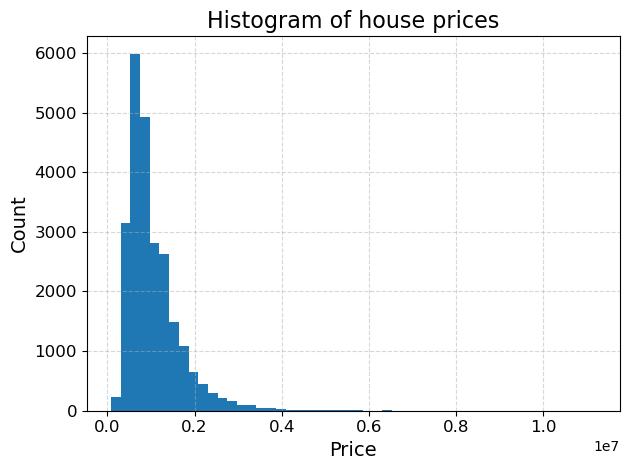

In [59]:
plt.hist(df["Price"], bins=50)

plt.title("Histogram of house prices", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

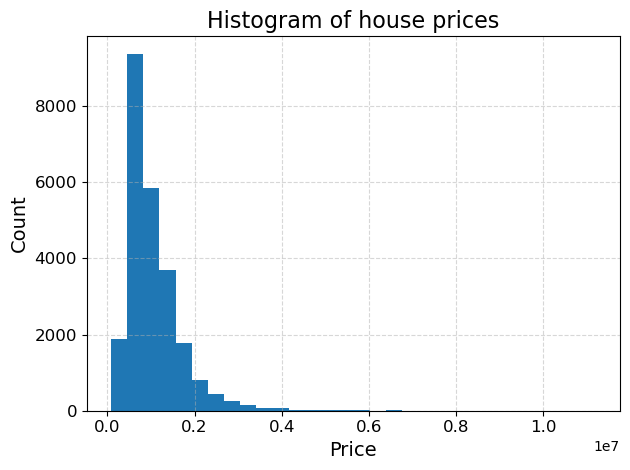

In [60]:
plt.hist(df["Price"], bins=30)

plt.title("Histogram of house prices", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

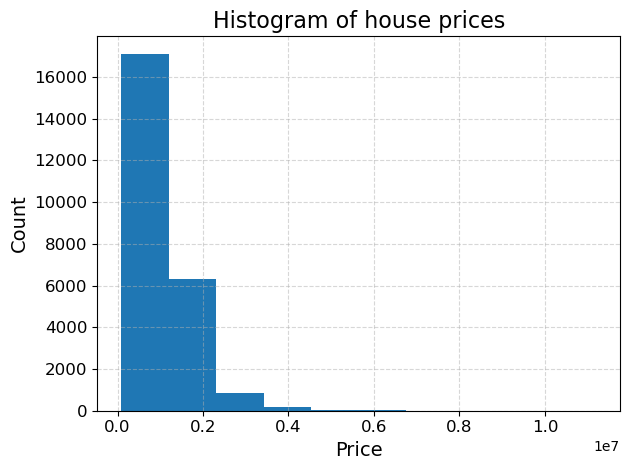

In [61]:
plt.hist(df["Price"], bins=10)

plt.title("Histogram of house prices", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

Now create a histogram of the year built. Determine a reasonable number of bins.

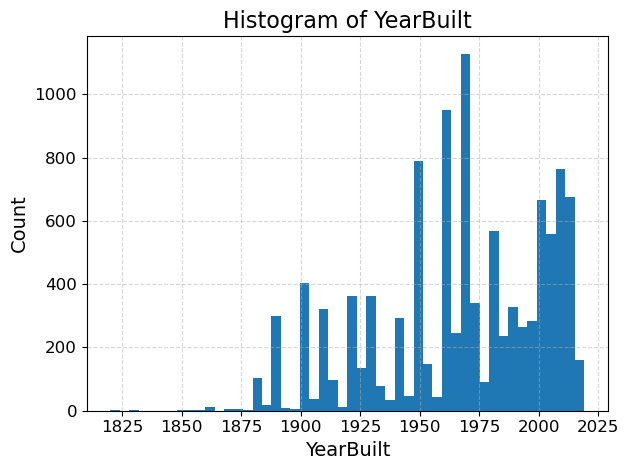

In [64]:
plt.hist(df['YearBuilt'], bins=50)

plt.title("Histogram of YearBuilt", fontsize=16)
plt.xlabel("YearBuilt", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Plot the landsize against the building area using a scatter plot.

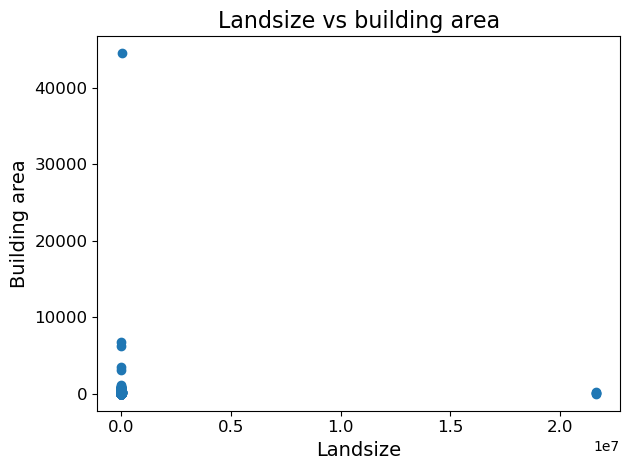

In [65]:
plt.scatter(df["Landsize"], df["BuildingArea"])

plt.title("Landsize vs building area", fontsize=16)
plt.xlabel("Landsize", fontsize=14)
plt.ylabel("Building area", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

This is quite a fail! We have to use the winsorized columns!

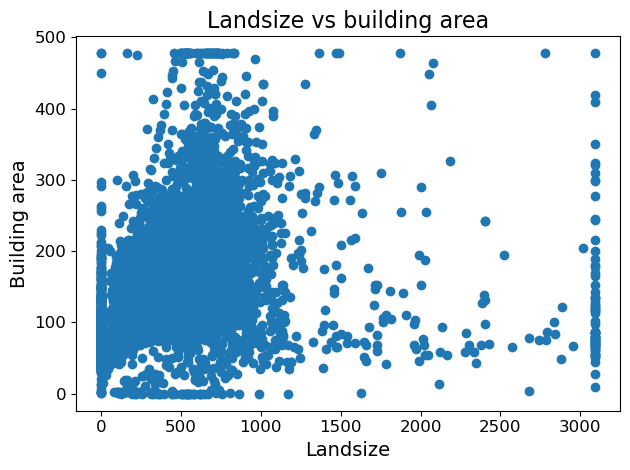

In [66]:
plt.scatter(df["Landsize_winsorized"], df["BuildingArea_winsorized"])

plt.title("Landsize vs building area", fontsize=16)
plt.xlabel("Landsize", fontsize=14)
plt.ylabel("Building area", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Extend the scatter plot, so that different house types are highlighted in a different color. For this purpose, checkout the notebook of Sheet 2a.

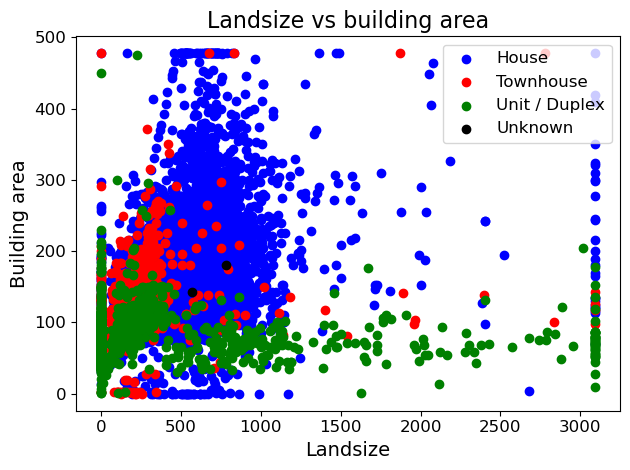

In [72]:
df_house = df[df["Type"] == "House"]
df_townhouse = df[df["Type"] == "Townhouse"]
df_unit = df[df["Type"] == "Unit / Duplex"]
df_unknown = df[df["Type"] == "Other"]

plt.scatter(df_house["Landsize_winsorized"], df_house["BuildingArea_winsorized"], c="blue", label="House")
plt.scatter(df_townhouse["Landsize_winsorized"], df_townhouse["BuildingArea_winsorized"], c="red", label="Townhouse")
plt.scatter(df_unit["Landsize_winsorized"], df_unit["BuildingArea_winsorized"], c="green", label="Unit / Duplex")
plt.scatter(df_unknown["Landsize_winsorized"], df_unknown["BuildingArea_winsorized"], c="black", label="Unknown")

plt.legend(loc="upper right", fontsize=12)
plt.title("Landsize vs building area", fontsize=16)
plt.xlabel("Landsize", fontsize=14)
plt.ylabel("Building area", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Plot a bar plot showing the mean land size per house type.

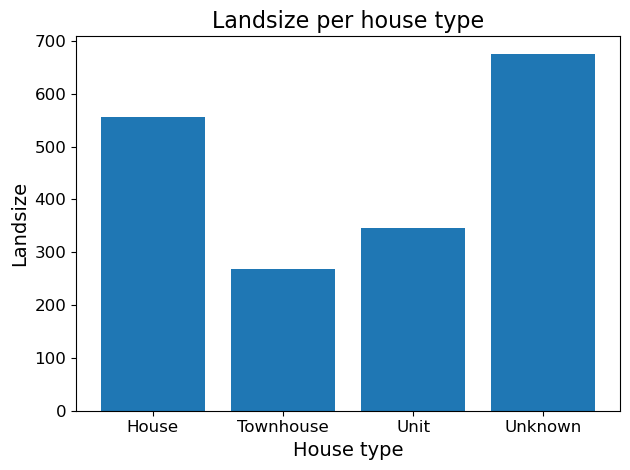

In [73]:
house_types = ["House", "Townhouse", "Unit", "Unknown"]
mean_landsize = [df_house["Landsize_winsorized"].mean(),
                 df_townhouse["Landsize_winsorized"].mean(),
                 df_unit["Landsize_winsorized"].mean(),
                 df_unknown["Landsize_winsorized"].mean()]

plt.bar(house_types, mean_landsize)

plt.title("Landsize per house type", fontsize=16)
plt.xlabel("House type", fontsize=14)
plt.ylabel("Landsize", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Now add the land size to the bar plot. You should hence create a grouped bar plot with the land size and building area next to each other.

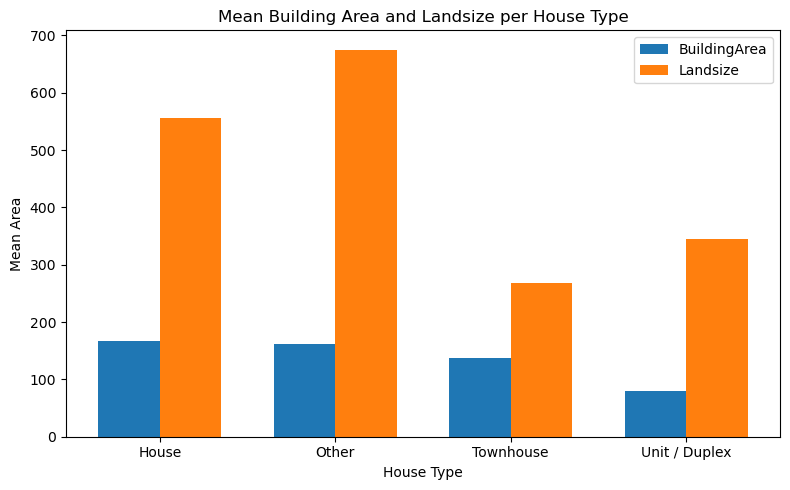

In [75]:
grouped = df.groupby(["Type"])[["BuildingArea_winsorized", "Landsize_winsorized"]].mean()

labels = grouped.index
x = np.arange(len(labels))

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, grouped["BuildingArea_winsorized"], width, label="BuildingArea")
plt.bar(x + width/2, grouped["Landsize_winsorized"], width, label="Landsize")

plt.xlabel("House Type")
plt.ylabel("Mean Area")
plt.title("Mean Building Area and Landsize per House Type")
plt.xticks(x, labels)
plt.legend()

plt.tight_layout()
plt.show()

Create a line plot to show the mean price for each YearBuilt. For this purpose, you have to aggregate the price per YearBuilt.

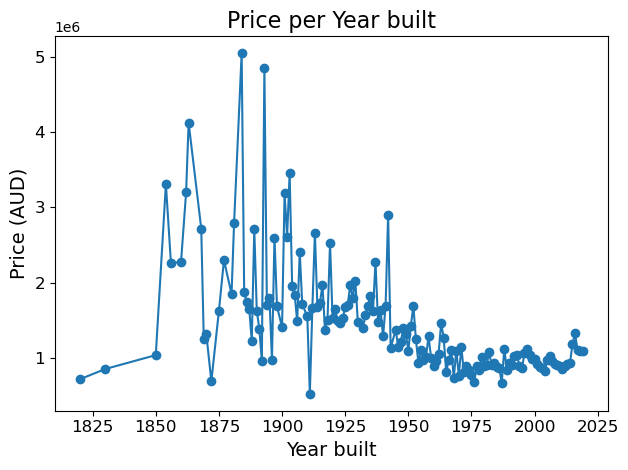

In [76]:
grouped = df.groupby(["YearBuilt"])["Price"].mean()

plt.plot(grouped.index, grouped.values, marker='o')

plt.title("Price per Year built", fontsize=16)
plt.xlabel("Year built", fontsize=14)
plt.ylabel("Price (AUD)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()